Task 1. Solve classification task (7 points)

Aknur Seidazym


In [2]:
import torch
import torchvision
from torchvision import transforms
from torchsummary import summary
from torch.utils.data import DataLoader,Dataset
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

1. Data preparation

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [4]:
ds = tfds.load('beans', split='train', shuffle_files=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/1034 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.9SXXGG_0.1.0/beans-train.tfrecord*...:   0%|          | 0…

Generating validation examples...:   0%|          | 0/133 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.9SXXGG_0.1.0/beans-validation.tfrecord*...:   0%|        …

Generating test examples...:   0%|          | 0/128 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.9SXXGG_0.1.0/beans-test.tfrecord*...:   0%|          | 0/…

Dataset beans downloaded and prepared to /root/tensorflow_datasets/beans/0.1.0. Subsequent calls will reuse this data.


In [5]:
ds

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(500, 500, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [6]:
df = tfds.as_dataframe(ds)

In [ ]:
df.head()

,image,label
0,"[[[129, 118, 88], [95, 81, 54], [84, 66, 46], ...",1
1,"[[[64, 88, 14], [65, 89, 15], [66, 88, 15], [6...",0
2,"[[[93, 109, 83], [96, 112, 86], [97, 115, 91],...",1
3,"[[[78, 103, 46], [86, 102, 53], [103, 103, 67]...",2
4,"[[[149, 123, 134], [117, 91, 102], [119, 88, 1...",1


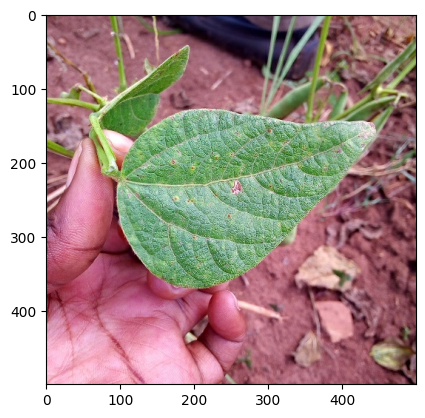

In [ ]:
plt.imshow(df['image'][0], cmap='gray')

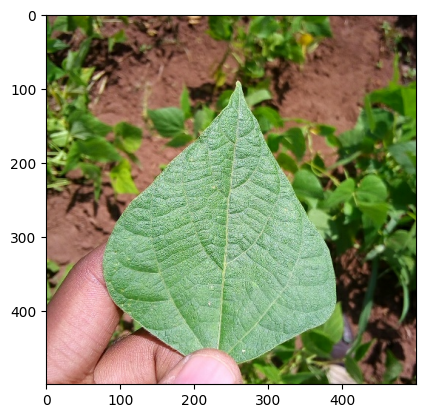

In [ ]:
plt.imshow(df['image'][3], cmap='gray')

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(np.array(df['image']), np.array(df['label']), test_size=0.2, random_state=10)

array([[[ 78, 103,  46],
        [ 86, 102,  53],
        [103, 103,  67],
        ...,
        [ 51,  32,  28],
        [ 56,  37,  33],
        [ 60,  41,  37]],

       [[ 76, 104,  45],
        [ 87, 105,  53],
        [103, 103,  65],
        ...,
        [ 48,  30,  26],
        [ 45,  27,  23],
        [ 40,  22,  18]],

       [[ 66,  98,  35],
        [ 78, 101,  45],
        [ 97,  99,  59],
        ...,
        [ 43,  28,  25],
        [ 36,  21,  18],
        [ 27,  12,   9]],

       ...,

       [[211, 143, 140],
        [207, 139, 136],
        [207, 137, 135],
        ...,
        [ 71,  64,  45],
        [ 71,  64,  45],
        [ 65,  58,  39]],

       [[216, 149, 143],
        [207, 140, 134],
        [203, 133, 131],
        ...,
        [ 75,  67,  48],
        [ 69,  61,  42],
        [ 61,  53,  34]],

       [[215, 148, 142],
        [210, 143, 137],
        [206, 136, 134],
        ...,
        [ 76,  65,  47],
        [ 60,  52,  33],
        [ 50,  42,  23]]], dtype=uint8)
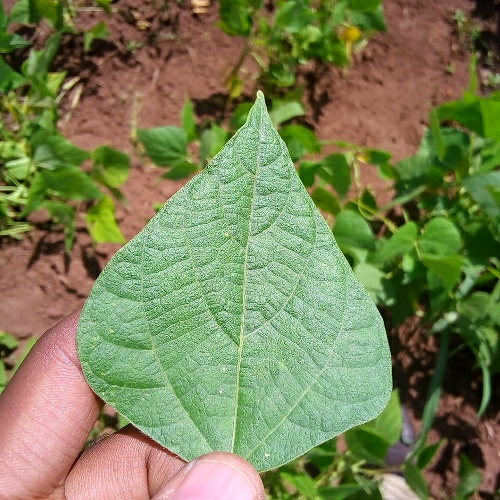

In [ ]:
df['image'][3]

In [ ]:
#your code here
#you can use code from lab with CNN for classification, but you will need to add extra layers. You can use any pretrained models adn data augmentation methods


In [8]:
# Print number of classes and their names
num_classes = len(np.unique(y_train))
class_names = np.unique(df['label'].values)
print("Number of classes:", num_classes)
print("Class names:", class_names)

Number of classes: 3
Class names: [0 1 2]


In [9]:
class MyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img = Image.fromarray(self.images[index])
        label = torch.tensor(self.labels[index], dtype=torch.long)
        if self.transform:
            img = self.transform(img)

        return img, label

# Define transformations for training and validation data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ResNet input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])






# Load the dataset
train_dataset = MyDataset(X_train, y_train, transform=train_transform)
test_dataset = MyDataset(X_test, y_test, transform=val_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
# Load pretrained ResNet18
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

# Modify the final fully connected layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),  # Add an intermediate layer
    nn.ReLU(),
    nn.Dropout(0.5),  # Dropout for regularization
    nn.Linear(512, 3)  # Output layer
)

# Move the model to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Only train the final layer
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Print training statistics
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    print(f'Validation Accuracy: {100 * val_correct / val_total:.2f}%')

Epoch [1/10], Loss: 0.9180, Accuracy: 57.19%
Validation Accuracy: 62.80%
Epoch [2/10], Loss: 0.6510, Accuracy: 73.16%
Validation Accuracy: 73.91%
Epoch [3/10], Loss: 0.4960, Accuracy: 78.96%
Validation Accuracy: 86.96%
Epoch [4/10], Loss: 0.4554, Accuracy: 81.50%
Validation Accuracy: 85.99%
Epoch [5/10], Loss: 0.4455, Accuracy: 82.59%
Validation Accuracy: 83.57%
Epoch [6/10], Loss: 0.3988, Accuracy: 85.01%
Validation Accuracy: 77.29%
Epoch [7/10], Loss: 0.4375, Accuracy: 83.07%
Validation Accuracy: 84.06%
Epoch [8/10], Loss: 0.3492, Accuracy: 85.97%
Validation Accuracy: 83.57%
Epoch [9/10], Loss: 0.3642, Accuracy: 85.73%
Validation Accuracy: 85.99%
Epoch [10/10], Loss: 0.3239, Accuracy: 87.42%
Validation Accuracy: 87.44%


Baseline accuracy more than 70 for all of classes AND more than 35 for each class
<br>**Please Note** each 1 missing from accuracy (for all or for each) will be evaluated as -0.5 from total grade

In [14]:
# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()  # Setting the model to evaluation mode
y_true = []  # Ground truth labels
y_pred = []  # Predicted

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        X_test_batch, y_test_batch = batch
        X_test_batch = X_test_batch.to(device=device, dtype=torch.float32)
        y_test_pred = model(X_test_batch)

        y_true.extend(y_test_batch.cpu().numpy())
        y_pred.extend(y_test_pred.cpu().detach())

# Converting our lists to NumPy arrays
test = np.array(y_true)

# Getting the predicted class labels
pred = np.argmax(np.array([tensor.numpy() for tensor in y_pred]), axis=1)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(test, pred))
print(classification_report(test, pred))


[[52 16  1]
 [ 3 63  1]
 [ 0  5 66]]
              precision    recall  f1-score   support

           0       0.95      0.75      0.84        69
           1       0.75      0.94      0.83        67
           2       0.97      0.93      0.95        71

    accuracy                           0.87       207
   macro avg       0.89      0.87      0.87       207
weighted avg       0.89      0.87      0.88       207



Write a function for classification of one image (3 points):
<br> Input: 1 image from dataset
<br> Output: predicted class, target class and comparison

In [ ]:
#your code here

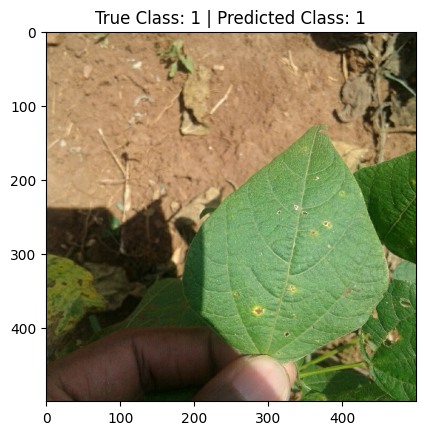

Predicted Class: 1 | True Class: 1
Correct Prediction: True



In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch

def classify_single_image(image_path, model, transform, class_names):
    # Loading and preprocessing the image
    img = Image.fromarray(image_path)
    img = img.resize((256, 256))
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

    # Makinging prediction
    model.eval()
    with torch.no_grad():
        img_tensor = img_tensor.to(device)
        prediction = model(img_tensor)

    # Converting prediction to class label
    predicted_class = torch.argmax(prediction).item()

    # Display the image
    plt.imshow(Image.fromarray(image_path))
    plt.title(f"True Class: {class_names[y_test[image_index]]} | Predicted Class: {class_names[predicted_class]}")
    plt.show()

    return predicted_class, y_test[image_index], predicted_class == y_test[image_index]

# Usage example:
image_index = 9
image_path = X_test[image_index]

predicted_class, true_class, correct = classify_single_image(image_path, model, val_transform, class_names)


print(f"Predicted Class: {class_names[predicted_class]} | True Class: {class_names[true_class]}")
print(f"Correct Prediction: {correct}\n")


Theoretical part (5 points)
<br> 1) Describe the reason of the use data augmentation
<br> 2) Provide example of metrics for solving classification, segmentation and object detection problem

## Data augmentation
It is a technique used to artificially increase the size and diversity of a training dataset by applying various transformations to the existing data. Reasons of using:
* Preventing Overfitting,
* Addressing Data Imbalance,
* Improving Model Robustness

## Classification Problems:

* Accuracy
* Precision
* Recall
* Confusion Matrix:
* AUC-ROC:

## Segmentation Problems:

* Intersection over Union (IoU)
* Dice Coefficient

## Object Detection Problems:

* mAP (Mean Average Precision)
* Precision and Recall
* IoU (Intersection over Union)
* F1-Score: The harmonic mean of precision and recall for object detection.
* False Positives per Image (FPI)